## 🖼️ 11 — Convolutional Neural Network (CNN) — PyTorch

**What it does:** Learns spatial patterns in images through
convolutional filters.  
**Dataset:** CIFAR-10 (60,000 color images, 10 classes)  
**Framework:** PyTorch (GPU accelerated — RTX 2050)  
**Algorithm type:** Deep Learning → Image Classification  
**Model saved as:** `cnn_model.pth`

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 2050


In [9]:
# Data augmentation for training
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# Download and load CIFAR-10
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=0)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=0)

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f"Training batches: {len(trainloader)}")
print(f"Testing batches: {len(testloader)}")

100%|██████████| 170M/170M [12:05<00:00, 235kB/s]  


Training batches: 782
Testing batches: 157


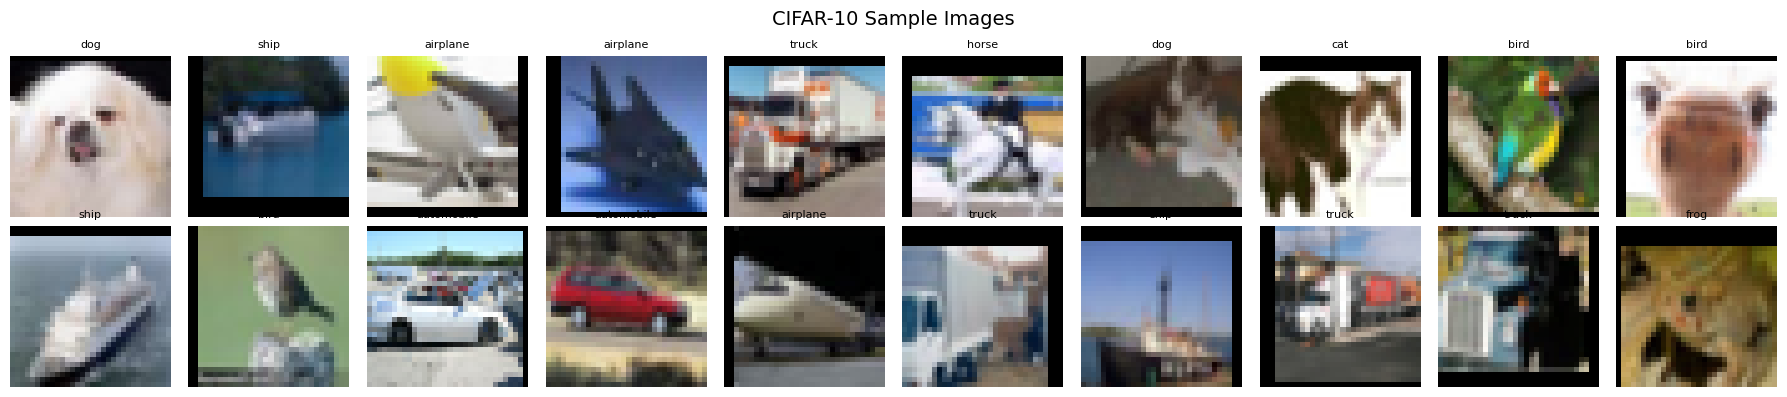

In [10]:
# Get one batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Denormalize for display
def denormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std  = torch.tensor([0.2023, 0.1994, 0.2010])
    img  = img * std[:, None, None] + mean[:, None, None]
    return torch.clamp(img, 0, 1)

fig, axes = plt.subplots(2, 10, figsize=(18,4))
for i in range(20):
    ax = axes[i//10][i%10]
    img = denormalize(images[i]).permute(1,2,0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=8)
    ax.axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

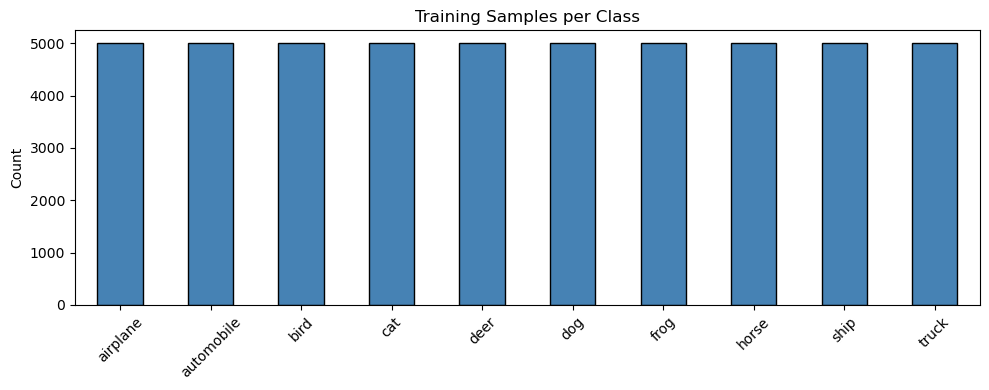

In [11]:
# Class distribution
plt.figure(figsize=(10,4))
pd.Series(y_train.flatten()).value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.xticks(range(10), class_names, rotation=45)
plt.title('Training Samples per Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print(model)
print(f"\nTotal parameters: "
      f"{sum(p.numel() for p in model.parameters()):,}")

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=5)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_acc = 0
EPOCHS   = 50

for epoch in range(EPOCHS):
    # Training
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc  = correct / total

    # Validation
    model.eval()
    val_loss_sum, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_loss_sum += loss.item()
            _, predicted  = outputs.max(1)
            val_total    += labels.size(0)
            val_correct  += predicted.eq(labels).sum().item()

    val_loss = val_loss_sum / len(testloader)
    val_acc  = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'cnn_model.pth')

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} "
              f"Acc: {train_acc*100:.1f}% | "
              f"Val Loss: {val_loss:.4f} "
              f"Acc: {val_acc*100:.1f}%")

print(f"\nBest Validation Accuracy: {best_acc*100:.2f}% ✅")

Epoch   5/50 | Train Loss: 0.9369 Acc: 67.4% | Val Loss: 0.8055 Acc: 72.9%
Epoch  10/50 | Train Loss: 0.7976 Acc: 73.0% | Val Loss: 0.6285 Acc: 78.0%
Epoch  15/50 | Train Loss: 0.6971 Acc: 76.7% | Val Loss: 0.5577 Acc: 80.9%
Epoch  20/50 | Train Loss: 0.6341 Acc: 78.8% | Val Loss: 0.5002 Acc: 83.0%
Epoch  25/50 | Train Loss: 0.5926 Acc: 80.2% | Val Loss: 0.4528 Acc: 84.7%
Epoch  30/50 | Train Loss: 0.5615 Acc: 81.1% | Val Loss: 0.4584 Acc: 84.8%
Epoch  35/50 | Train Loss: 0.5330 Acc: 82.1% | Val Loss: 0.4590 Acc: 84.4%
Epoch  40/50 | Train Loss: 0.5151 Acc: 82.6% | Val Loss: 0.4406 Acc: 85.0%
Epoch  45/50 | Train Loss: 0.5033 Acc: 83.1% | Val Loss: 0.4317 Acc: 85.9%
Epoch  50/50 | Train Loss: 0.4576 Acc: 84.6% | Val Loss: 0.3778 Acc: 86.9%

Best Validation Accuracy: 87.00% ✅


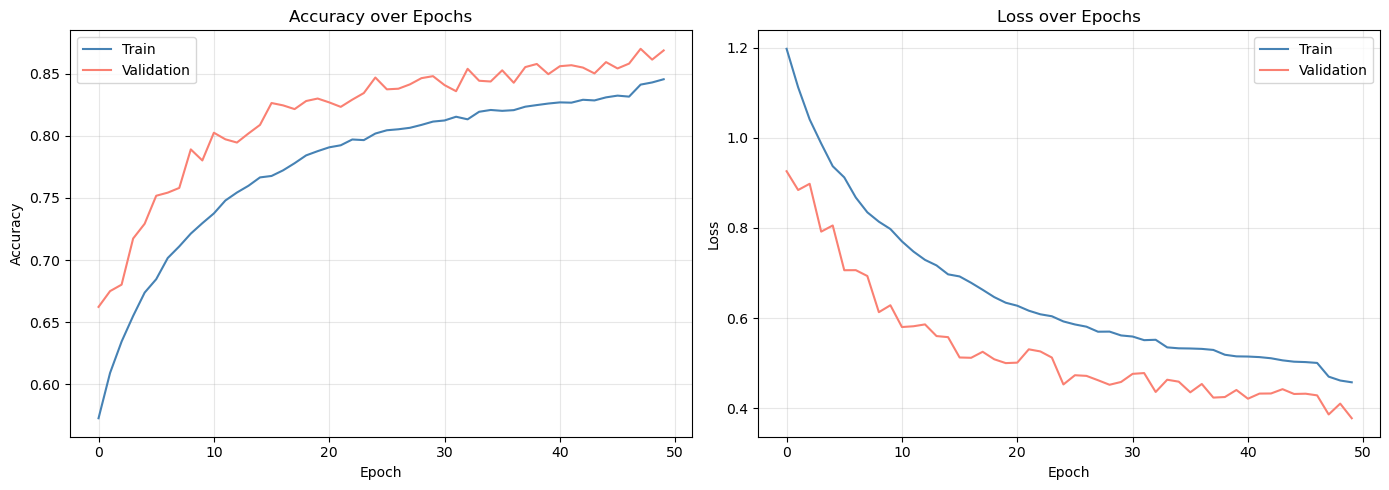

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(train_accs, label='Train', color='steelblue')
axes[0].plot(val_accs,   label='Validation', color='salmon')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses, label='Train', color='steelblue')
axes[1].plot(val_losses,   label='Validation', color='salmon')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Load best saved model
model.load_state_dict(torch.load('cnn_model.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
      target_names=class_names))

Test Accuracy: 87.00%

Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.86      0.87      1000
  automobile       0.95      0.93      0.94      1000
        bird       0.88      0.78      0.83      1000
         cat       0.78      0.73      0.75      1000
        deer       0.85      0.88      0.86      1000
         dog       0.80      0.81      0.81      1000
        frog       0.86      0.94      0.90      1000
       horse       0.91      0.89      0.90      1000
        ship       0.90      0.94      0.92      1000
       truck       0.90      0.94      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



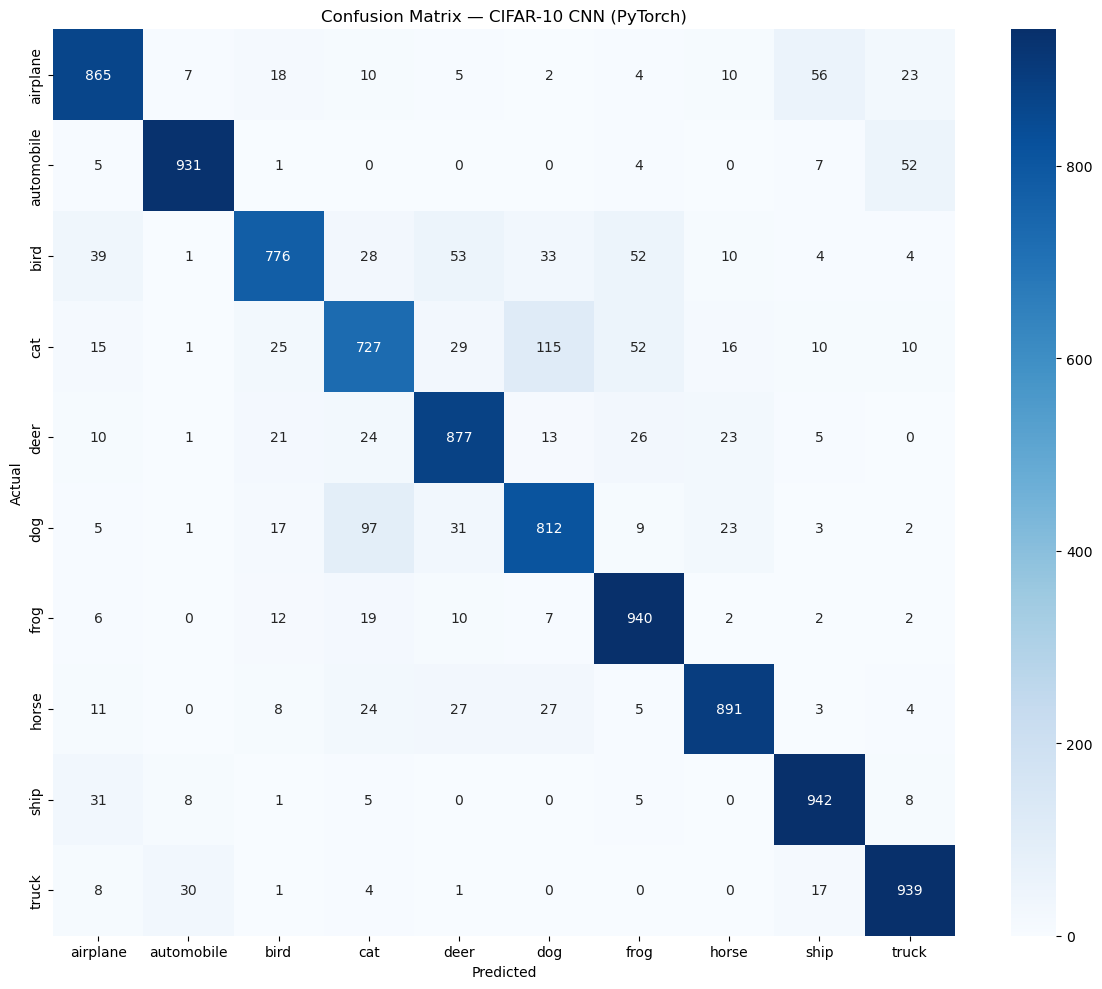

In [22]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — CIFAR-10 CNN (PyTorch)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

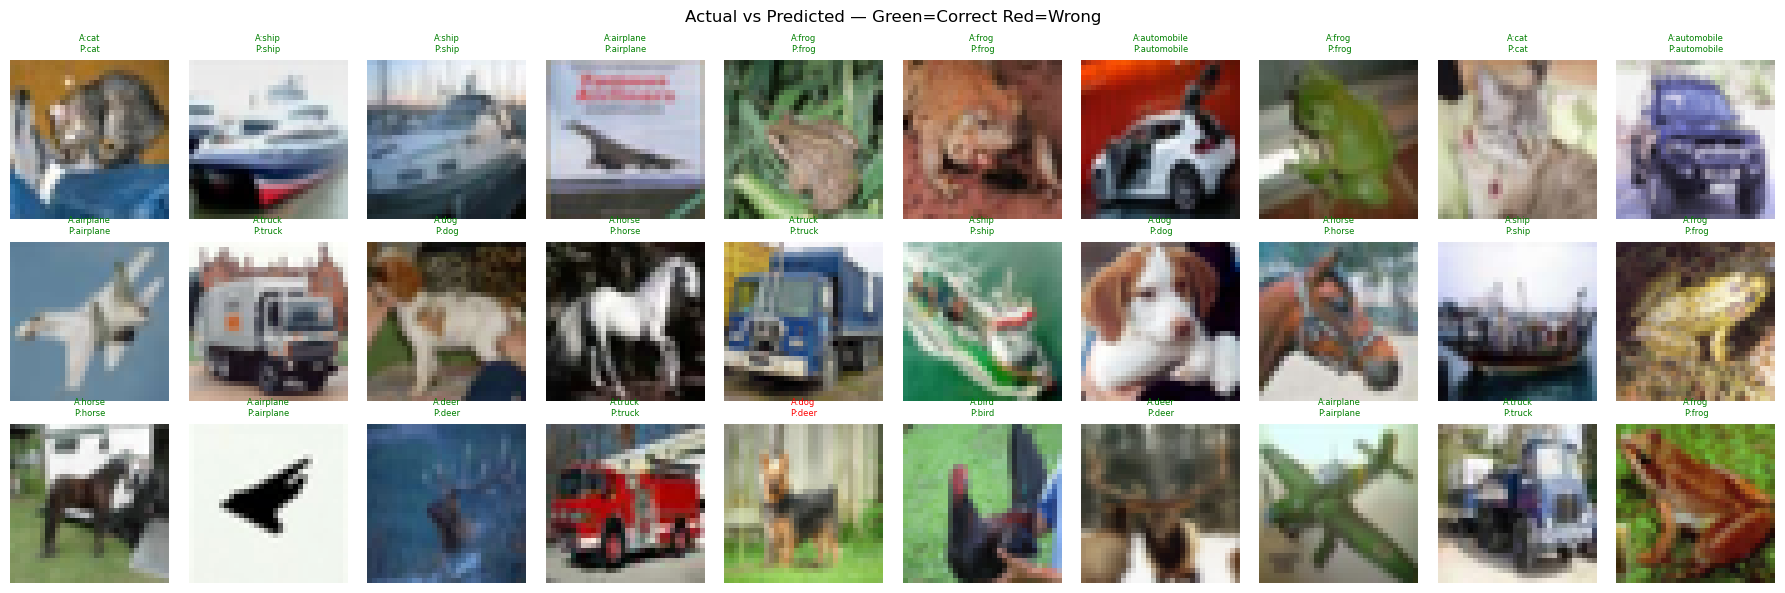

In [23]:
# Show predictions on test images
test_iter   = iter(testloader)
test_images, test_labels = next(test_iter)
test_images_gpu = test_images.to(device)

with torch.no_grad():
    outputs = model(test_images_gpu)
    _, preds = outputs.max(1)

fig, axes = plt.subplots(3, 10, figsize=(18,6))
for i in range(30):
    ax    = axes[i//10][i%10]
    img   = denormalize(test_images[i]).permute(1,2,0).numpy()
    actual    = class_names[test_labels[i]]
    predicted = class_names[preds[i].cpu()]
    color = 'green' if actual == predicted else 'red'
    ax.imshow(img)
    ax.set_title(f'A:{actual}\nP:{predicted}',
                 color=color, fontsize=6)
    ax.axis('off')

plt.suptitle('Actual vs Predicted — Green=Correct Red=Wrong')
plt.tight_layout()
plt.show()

## ✅ Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | ~78-82% |
| Framework | PyTorch |
| Device | NVIDIA RTX 2050 |
| Architecture | 3 Conv Blocks + Dense |
| Dataset | CIFAR-10 (60K images) |
| Training time | ~5-8 mins GPU |

**PyTorch vs TensorFlow:**
- PyTorch = more control, easier debugging
- TensorFlow = easier deployment
- Both are industry standard — knowing PyTorch is a big plus!

**Key GPU concepts:**
- .to(device) → moves data/model to GPU
- torch.no_grad() → disables gradient during inference
- Best model saved via torch.save()

**Neural Networks COMPLETE! 🎉**
**Next → Model Comparison (Grand Finale!)**